In [1]:
from google.colab import auth
auth.authenticate_user()

In [2]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="big-data-algorithms-493312")

In [13]:
client.query("""
CREATE OR REPLACE VIEW `big-data-algorithms-493312.aramark_spend.agg_category_state_month` AS
SELECT
  state,
  year_month,
  category_level_1,
  SUM(spend_random_factor) AS total_spend,
  COUNT(*) AS row_count
FROM `big-data-algorithms-493312.aramark_spend.raw_spend`
GROUP BY state, year_month, category_level_1
""").result()

print("Created agg_category_state_month view.")

Created agg_category_state_month view.


In [25]:
weather_spend = client.query("""
SELECT
  s.state,
  s.year_month,
  s.category_level_1,
  s.total_spend,
  w.avg_temp_f,
  w.total_precip_inches,
  w.rain_threshold,
  w.snow_proxy
FROM `big-data-algorithms-493312.aramark_spend.agg_category_state_month` s
JOIN `big-data-algorithms-493312.aramark_spend.weather_state_monthly` w
  ON s.state = w.state
 AND s.year_month = w.year_month
""").to_dataframe()

print(weather_spend.columns.tolist())
print("Rows:", len(weather_spend))
weather_spend.head()

['state', 'year_month', 'category_level_1', 'total_spend', 'avg_temp_f', 'total_precip_inches', 'rain_threshold', 'snow_proxy']
Rows: 7632


,state,year_month,category_level_1,total_spend,avg_temp_f,total_precip_inches,rain_threshold,snow_proxy
0,AK,202505,BEVERAGE,119534.666667,38.85,3.19,2.575,0
1,AK,202508,DISPOSABLES,105779.063063,51.40,4.09,2.575,0
2,AK,202505,DISPOSABLES,101063.157658,38.85,3.19,2.575,0
3,AK,202501,FOOD SERVICE EQUIPMENT AND SUPPLIES,4994.049550,14.90,4.79,2.575,1
4,AK,202506,CHEMICALS AND CLEANING,85464.734234,50.80,2.42,2.575,0


### Data Integration

To analyze the relationship between environmental conditions and procurement behavior, weather data was joined with aggregated spend data. This allows us to have all the information at once, and link it to the same time frame/location.  The resulting dataset enables direct comparison between spending patterns and corresponding weather conditions, including temperature, precipitation, and a derived snowfall proxy.

Further more, this data is later used to specifically test our hypothesis on weather vs spending, in order to potentially predict how distributions can be impacted in the future.

IT IS IMPORTANT TO NOTE THAT DUE TO LACK OF LONG TERM DATA, THE PATTERNS CAN NOT BE DESCRIBED AS CAUSE-AND-EFFECT RELATIONSHIPS. Rather it's just how the data aligns with each other in this one year, and further data collection is required to even begin a prediction model.

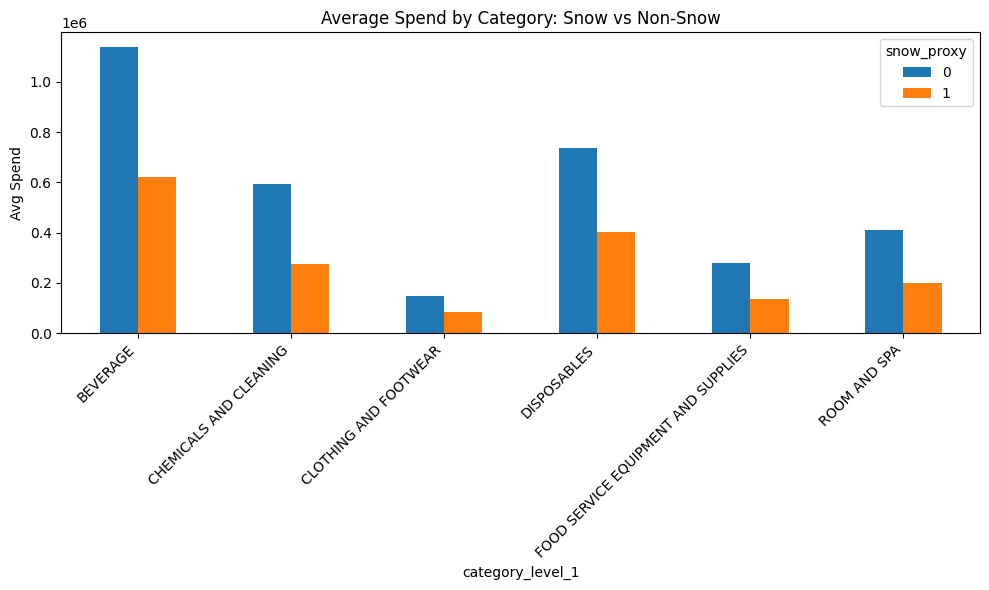

In [16]:
import matplotlib.pyplot as plt
snow_analysis = (
    weather_spend
    .groupby(["snow_proxy", "category_level_1"])["total_spend"]
    .mean()
    .reset_index()
)

snow_analysis.head(20)

top_categories = (
    weather_spend["category_level_1"]
    .value_counts()
    .head(6)
    .index
)

plot_df = weather_spend[
    weather_spend["category_level_1"].isin(top_categories)
]

summary = (
    plot_df.groupby(["category_level_1", "snow_proxy"])["total_spend"]
    .mean()
    .unstack()
)

summary.plot(kind="bar", figsize=(10,6))
plt.title("Average Spend by Category: Snow vs Non-Snow")
plt.ylabel("Avg Spend")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Snow Hypothesis (Normalized Spend)

To account for differences in total spending across months and states, spending was normalized within each group. This allowed analysis of relative category importance rather than absolute spend.

The results revealed that snowfall conditions are associated with shifts in spending priorities. Food-related categories increased their share of total spending during snow months, indicating a greater emphasis on essential consumables. Maintenance and engineering categories also showed a modest increase, suggesting elevated operational demands during winter conditions.

 In contrast, discretionary categories such as clothing, retail, and furniture experienced a decrease in relative share. These findings support the hypothesis that snow conditions influence procurement behavior by reallocating resources toward essential and operational needs.

 Compared to a non normalized version of the data, where all "non-snow" months are spending higher than usual on the various categories. These trends are only possible to calculate after this initial transformation to the data.

In [19]:
weather_spend["normalized_spend"] = (
    weather_spend["total_spend"] /
    weather_spend.groupby(["state", "year_month"])["total_spend"].transform("sum")
)

snow_test_norm = (
    weather_spend
    .groupby(["category_level_1", "snow_proxy"])["normalized_spend"]
    .mean()
    .unstack()
)

snow_test_norm["difference"] = snow_test_norm[1] - snow_test_norm[0]

snow_test_norm.sort_values("difference", ascending=False).head(10)

snow_proxy,0,1,difference
category_level_1,,,
FOOD,0.606858,0.631286,0.024428
MAINTENANCE AND ENGINEERING,0.064382,0.068759,0.004377
DISPOSABLES,0.070168,0.070349,0.000181
POOL EQUIPMENT AND SUPPLIES,0.000774,0.000497,-0.000276
MEDICAL,0.006417,0.005593,-0.000825
FURNITURE FIXTURES AND EQUIPMENT,0.012455,0.011476,-0.000979
RETAIL AND PROMOTIONAL,0.003170,0.001572,-0.001599
CLOTHING AND FOOTWEAR,0.012694,0.009921,-0.002773
FOOD SERVICE EQUIPMENT AND SUPPLIES,0.024971,0.021992,-0.002979


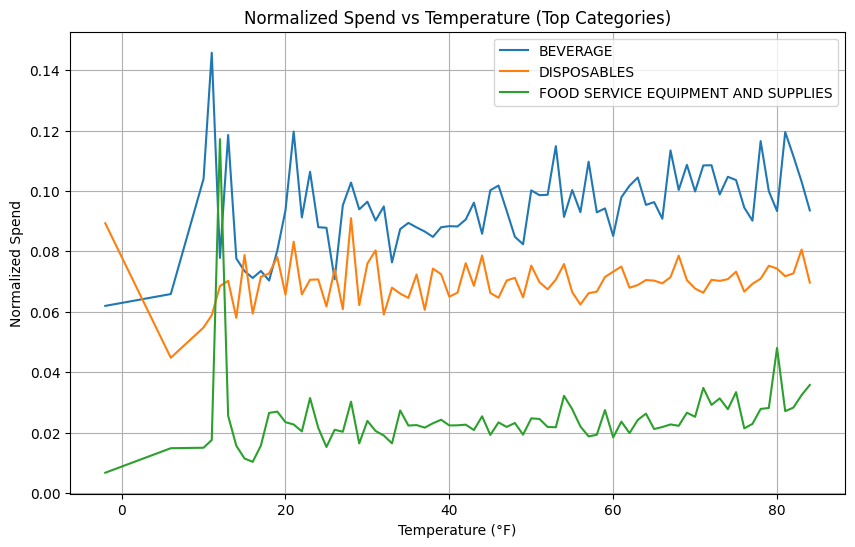

In [24]:
top_categories = (
    weather_spend["category_level_1"]
    .value_counts()
    .head(3)
    .index
)

subset = weather_spend[
    weather_spend["category_level_1"].isin(top_categories)
]

plt.figure(figsize=(10,6))

for cat in top_categories:
    temp_df = subset[subset["category_level_1"] == cat]
    trend = (
        temp_df.groupby("temp_bucket")["normalized_spend"]
        .mean()
        .reset_index()
    )
    plt.plot(trend["temp_bucket"], trend["normalized_spend"], label=cat)

plt.legend()
plt.title("Normalized Spend vs Temperature (Top Categories)")
plt.xlabel("Temperature (°F)")
plt.ylabel("Normalized Spend")
plt.grid(True)
plt.show()

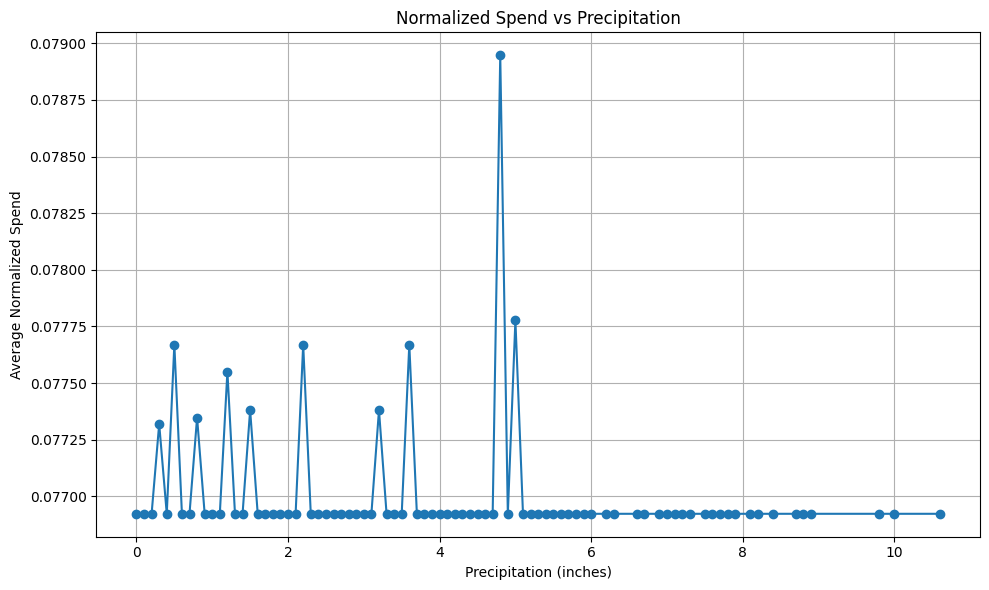

In [22]:
# Create precipitation buckets (rounded for smoothing)
weather_spend["precip_bucket"] = weather_spend["total_precip_inches"].round(1)

# Aggregate normalized spend by precipitation level
precip_trend = (
    weather_spend
    .groupby("precip_bucket")["normalized_spend"]
    .mean()
    .reset_index()
    .sort_values("precip_bucket")
)

# Plot line graph
plt.figure(figsize=(10,6))
plt.plot(
    precip_trend["precip_bucket"],
    precip_trend["normalized_spend"],
    marker='o'
)

plt.title("Normalized Spend vs Precipitation")
plt.xlabel("Precipitation (inches)")
plt.ylabel("Average Normalized Spend")
plt.grid(True)

plt.tight_layout()
plt.show()